In [17]:
# EXPERIMENT 7 - AIML LAB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# STEP 1: Load Dataset
df = pd.read_csv("titanic.csv")

# Use a numerical column (Fare)
df = df[['fare']].dropna()
df.rename(columns={'fare': 'Values'}, inplace=True)

In [20]:
# STEP 2: Feature Scaling
# Min-Max Scaling
df['MinMax'] = (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min())

# Z-score (Standard Deviation)
df['Z_std'] = (df['Values'] - df['Values'].mean()) / df['Values'].std()

# Z-score (MAD)
mad = (df['Values'] - df['Values'].mean()).abs().mean()
df['Z_MAD'] = (df['Values'] - df['Values'].mean()) / mad

# Decimal Scaling
j = len(str(int(df['Values'].abs().max())))
df['Decimal'] = df['Values'] / (10 ** j)

print("Final Data with Scaling:\n")
print(df.head())

Final Data with Scaling:

    Values    MinMax     Z_std     Z_MAD   Decimal
0   7.2500  0.014151 -0.502163 -0.886042  0.007250
1  71.2833  0.139136  0.786404  1.387570  0.071283
2   7.9250  0.015469 -0.488580 -0.862075  0.007925
3  53.1000  0.103644  0.420494  0.741941  0.053100
4   8.0500  0.015713 -0.486064 -0.857636  0.008050


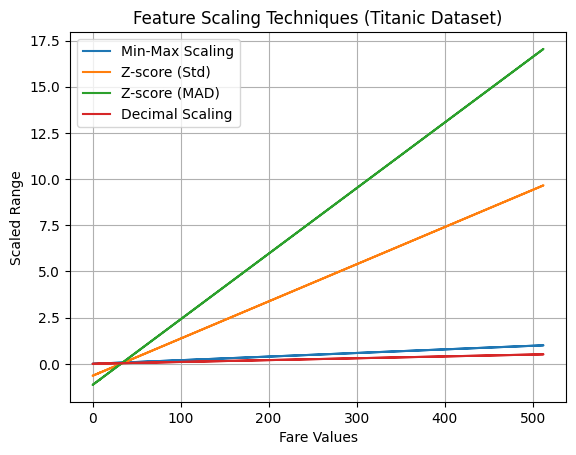

In [21]:
#STEP 3: Plot Graph
plt.figure()
plt.plot(df['Values'], df['MinMax'], label='Min-Max Scaling')
plt.plot(df['Values'], df['Z_std'], label='Z-score (Std)')
plt.plot(df['Values'], df['Z_MAD'], label='Z-score (MAD)')
plt.plot(df['Values'], df['Decimal'], label='Decimal Scaling')

plt.xlabel("Fare Values")
plt.ylabel("Scaled Range")
plt.title("Feature Scaling Techniques (Titanic Dataset)")

plt.legend()
plt.grid()
plt.show()

In [22]:
# STEP 4: Dataset Splitting
def split_data(data, train_ratio, val_ratio, test_ratio):
    shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(data)

    train_end = round(train_ratio * n)
    val_end = train_end + round(val_ratio * n)
    train = shuffled[:train_end]
    val = shuffled[train_end:val_end]
    test = shuffled[val_end:]

    return train, val, test

In [14]:
# STEP 5: Apply Different Splits
splits = [
    (0.7, 0.2, 0.1),
    (0.7, 0.1, 0.2),
    (0.6, 0.2, 0.2)
]

for i, (tr, va, te) in enumerate(splits, 1):
    train, val, test = split_data(df, tr, va, te)

    print(f"\nSplit {i}: Train={tr*100}%, Validation={va*100}%, Test={te*100}%")

    print("\nTrain Data:\n", train.head())
    print("\nValidation Data:\n", val.head())
    print("\nTest Data:\n", test.head())


Split 1: Train=70.0%, Validation=20.0%, Test=10.0%

Train Data:
    Marks    MinMax     Z_std     Z_MAD  Decimal
0    117  0.828283  1.147787  1.455285    0.117
1     47  0.121212 -1.096489 -1.390244    0.047
2     82  0.474747  0.025649  0.032520    0.082
3     35  0.000000 -1.481222 -1.878049    0.035
4    105  0.707071  0.763054  0.967480    0.105
5     59  0.242424 -0.711756 -0.902439    0.059
6    134  1.000000  1.692826  2.146341    0.134

Validation Data:
    Marks    MinMax     Z_std     Z_MAD  Decimal
7     74  0.393939 -0.230840 -0.292683    0.074
8     68  0.333333 -0.423206 -0.536585    0.068

Test Data:
    Marks    MinMax     Z_std     Z_MAD  Decimal
9     91  0.565657  0.314199  0.398374    0.091

Split 2: Train=70.0%, Validation=10.0%, Test=20.0%

Train Data:
    Marks    MinMax     Z_std     Z_MAD  Decimal
0    117  0.828283  1.147787  1.455285    0.117
1     47  0.121212 -1.096489 -1.390244    0.047
2     82  0.474747  0.025649  0.032520    0.082
3     35  0.000000 -